# Landslide Risk Prediction Random Forest

This notebook is a self-contained guide to how the Random Forest model works on the landslide dataset.

It walks through the same learning steps a reader would expect in a project notebook: loading the data, exploring it, splitting it, scaling it, training a Random Forest, evaluating the result, and making a single prediction.

The notebook does not depend on backend project code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
%matplotlib inline

## Data Collection and Exploratory Inspection

We start by loading the raw dataset directly from the project data folder, then we inspect the shape, summary statistics, and class balance.

In [2]:
# Load the landslide dataset directly from the project data folder.
# This keeps the notebook self-contained and easy to understand for new users.
landslide_data = pd.read_csv('../data/raw/landslide_dataset.csv', header=0)

In [3]:
# Generate summary statistics for the numeric columns.
# This helps us understand ranges and spread before training the model.
landslide_data.describe()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Landslide,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.0000,2000.00000
mean,176.688462,29.985404,0.540316,0.522862,3.604771,1.001867,0.500000,0.25850,0.2415,0.26100
std,65.724685,15.175902,0.295665,0.260426,1.895955,0.579964,0.500125,0.43792,0.4281,0.43929
min,50.036151,5.003944,0.000652,0.100005,0.001641,0.000653,0.000000,0.00000,0.0000,0.00000
25%,128.379762,18.018061,0.265634,0.295475,1.973415,0.500808,0.000000,0.00000,0.0000,0.00000
50%,177.013772,27.772833,0.599887,0.500191,3.996429,0.999761,0.500000,0.00000,0.0000,0.00000
75%,228.742286,41.683190,0.801994,0.740690,5.233897,1.505294,1.000000,1.00000,0.0000,1.00000
max,299.919102,59.966732,0.998831,0.999837,6.498670,1.999636,1.000000,1.00000,1.0000,1.00000


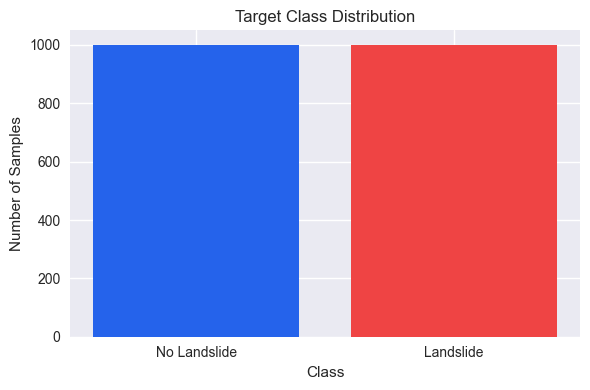

In [4]:
# Visualize the class distribution so we can see how many examples belong to each label.
class_counts = landslide_data['Landslide'].value_counts().sort_index()
class_labels = ['No Landslide', 'Landslide']

plt.figure(figsize=(6, 4))
plt.bar(class_labels, class_counts.values, color=['#2563eb', '#ef4444'])
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

In [5]:
# Compare the average values for each class to see broad feature differences.
landslide_data.groupby('Landslide').mean()

,Rainfall_mm,Slope_Angle,Soil_Saturation,Vegetation_Cover,Earthquake_Activity,Proximity_to_Water,Soil_Type_Gravel,Soil_Type_Sand,Soil_Type_Silt
Landslide,,,,,,,,,
0,127.111331,17.717390,0.282473,0.748140,1.974215,1.502907,0.517,0.483,0.000
1,226.265592,42.253418,0.798160,0.297583,5.235326,0.500827,0.000,0.000,0.522


In [6]:
# Separate features from the target label.
# All columns except 'Landslide' are used as inputs for the model.
X = landslide_data.drop(columns=['Landslide'])
Y = landslide_data['Landslide']

print('Feature columns:')
print(list(X.columns))
print('\nX shape:', X.shape)
print('Y shape:', Y.shape)

Feature columns:
['Rainfall_mm', 'Slope_Angle', 'Soil_Saturation', 'Vegetation_Cover', 'Earthquake_Activity', 'Proximity_to_Water', 'Soil_Type_Gravel', 'Soil_Type_Sand', 'Soil_Type_Silt']

X shape: (2000, 9)
Y shape: (2000,)


## Feature and Target Separation

The model uses the feature columns from the dataset in a fixed order so training and prediction stay consistent.

In [7]:
# Split the dataset into training and testing sets using stratification so both splits keep the class balance.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

# Scale the numeric features to keep the workflow consistent with the project notebook style.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Unscaled train shape:', X_train.shape)
print('Unscaled test shape:', X_test.shape)
print('Scaled train shape:', X_train_s.shape)
print('Scaled test shape:', X_test_s.shape)

Unscaled train shape: (1600, 9)
Unscaled test shape: (400, 9)
Scaled train shape: (1600, 9)
Scaled test shape: (400, 9)


## Train/Test Split and Feature Scaling

The dataset is split into training and testing subsets, then standardized so the workflow is easy to follow and the feature scale is consistent.

In [8]:
# Train the Random Forest classifier with the same hyperparameters used in the project.
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
 )

model.fit(X_train_s, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Model Training

We train a Random Forest classifier with the same hyperparameters used in the project model so the notebook reflects the real training setup.

In [9]:
# Evaluate the model on both training and test data.
Y_train_prediction = model.predict(X_train_s)
Y_test_prediction = model.predict(X_test_s)

training_data_accuracy = accuracy_score(Y_train, Y_train_prediction)
test_data_accuracy = accuracy_score(Y_test, Y_test_prediction)
test_auc = roc_auc_score(Y_test, model.predict_proba(X_test_s)[:, 1])

print('Accuracy on training data:', training_data_accuracy)
print('Accuracy on test data:', test_data_accuracy)
print('Test AUC:', test_auc)
print('\nClassification Report:\n')
print(classification_report(Y_test, Y_test_prediction, digits=4))

Accuracy on training data: 1.0
Accuracy on test data: 1.0
Test AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400



## Evaluation and Interpretation

We measure accuracy, AUC, and print the classification report. The feature-importance chart adds an interpretation layer for the Random Forest model.

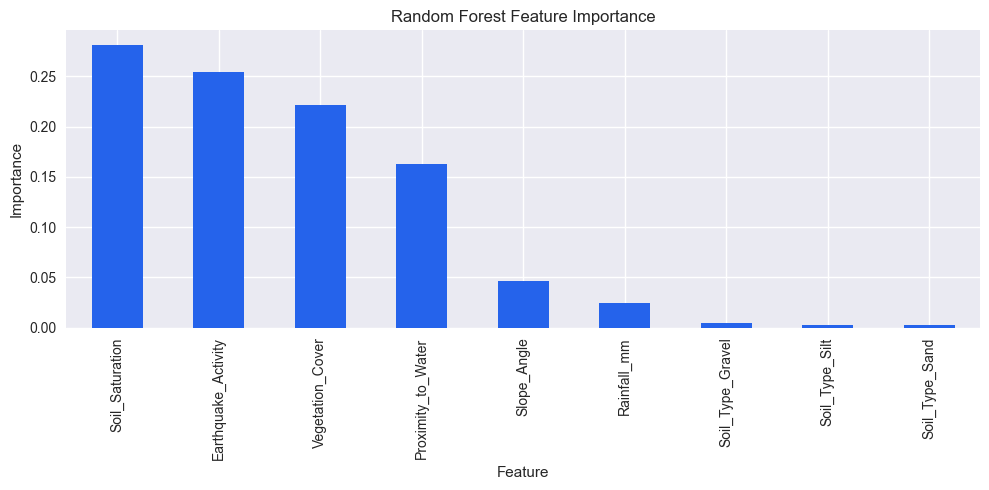

In [10]:
# Visualize the Random Forest feature importance scores to see which inputs influence the model most.
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feature_importances.plot(kind='bar', color='#2563eb')
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Prediction Example

The trained Random Forest can also be used for a single custom input row. The input values must follow the same feature order used during training.

In [12]:
# Example inference using one custom input row.
# The feature order must match the training features exactly.
# Use a DataFrame with the same feature names used during training so the scaler receives matching columns.
input_data = pd.DataFrame([[
    206.1810178271, 58.2750007243, 0.8927975767, 0.3394633937,
    4.3900466011, 0.0999749158, 0, 0, 0
]], columns=X.columns)

input_data_scaled = scaler.transform(input_data)
prediction = model.predict(input_data_scaled)
prediction_proba = model.predict_proba(input_data_scaled)

print('Prediction:', prediction[0])
print('Probability of landslide:', round(float(prediction_proba[0][1]), 4))

if prediction[0] == 0:
    print('No landslide')
else:
    print('Landslide likely')

Prediction: 1
Probability of landslide: 1.0
Landslide likely


## Conclusion

This notebook shows the Random Forest workflow in a self-contained way so a reader can understand how the model learns from the landslide dataset.

It does not rely on backend code imports, so it can be opened as a standalone learning notebook.